# Analisis de Errores y Slicing

## Setup y Carga del Modelo Baseline

Reconstruimos el pipeline completo a partir del sprint 3: datos con feature engineering, el mejor modelo (XGBoost Optuna), y generamos predicciones con probabilidades sobre el test set para el analisis de errores.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import random
import shap
import time
from scipy import stats
from scipy.interpolate import interp1d

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, auc,
    confusion_matrix, classification_report,
    brier_score_loss, log_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Semilla fija para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Directorio de salida
OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figs", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)

print('=== Sprint 4: Analisis de Errores y Slicing ===')
print(f'Output directory: {OUTPUT_DIR}')

=== Sprint 4: Analisis de Errores y Slicing ===
Output directory: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4


## Carga de Datos con Feature Engineering

Usamos los datos procesados del sprint 3 (entrenamiento balanceado + prueba con feature engineering).

In [2]:
# ============================================================
# CARGA DE DATOS
# ============================================================
# Ruta de datos (mismo config del sprint 3)
TRAIN_PATH = "/workspaces/proyecto-zona-interes-Au/data/interim/data_entrenamiento_balanceado_fe.csv"
TEST_PATH = "/workspaces/proyecto-zona-interes-Au/data/interim/data_prueba_fe.csv"

# Cargar datos
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

# Columnas a excluir
exclude = ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']
features = [col for col in df_train.columns if col not in exclude]

# Separar features y target
X_train = df_train[features].copy()
y_train = df_train['target_Au'].copy()
coords_train = df_train[['East', 'North', 'Level']].copy()

X_test = df_test[features].copy()
y_test = df_test['target_Au'].copy()
coords_test = df_test[['East', 'North', 'Level']].copy()

# Ag_ppm y Au_ppm reales para analisis (si existen en test)
if 'Au_ppm' in df_test.columns:
    au_test_real = df_test['Au_ppm'].copy()
else:
    au_test_real = None

print(f'Datos cargados:')
print(f'  Train: {X_train.shape[0]} muestras, {len(features)} features')
print(f'  Test:  {X_test.shape[0]} muestras, {len(features)} features')
print(f'  Features: {len(features)}')
print(f'  Target balance (train): {y_train.value_counts().to_dict()}')
print(f'  Target balance (test):  {y_test.value_counts().to_dict()}')
print(f'\nPrimeras 5 features: {features[:5]}')
print(f'Ultimas 5 features: {features[-5:]}')

Datos cargados:
  Train: 2994 muestras, 57 features
  Test:  427 muestras, 57 features
  Features: 57
  Target balance (train): {0: 1497, 1: 1497}
  Target balance (test):  {0: 375, 1: 52}

Primeras 5 features: ['Ag_ppm', 'Al_per', 'As_ppm', 'Ba_ppm', 'Be_ppm']
Ultimas 5 features: ['Pb_Zn_ratio', 'Bi_As_ratio', 'pathfinder_sum', 'pathfinder_mean', 'pathfinder_max']


## Entrenamiento del Modelo Baseline (XGBoost Optuna)

Re-entrenamos el mejor modelo del sprint 3 para obtener predicciones y probabilidades sobre el test set. Este sera nuestro **baseline** para comparar contra las mitigaciones.

In [3]:
# ============================================================
# ENTRENAMIENTO MODELO BASELINE
# ============================================================
# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mejor modelo: XGBoost Optuna (del sprint 3)
xgb_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': SEED,
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'use_label_encoder': False
}

baseline_model = xgb.XGBClassifier(**xgb_params)
baseline_model.fit(X_train_scaled, y_train)

# Predicciones y probabilidades
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Metricas globales baseline
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall': recall_score(y_test, y_pred_baseline, zero_division=0),
    'F1': f1_score(y_test, y_pred_baseline, zero_division=0),
    'PR_AUC': average_precision_score(y_test, y_prob_baseline),
    'ROC_AUC': roc_auc_score(y_test, y_prob_baseline),
    'Brier': brier_score_loss(y_test, y_prob_baseline)
}

print('=== METRICAS GLOBALES - BASELINE ===')
for k, v in baseline_metrics.items():
    print(f'  {k:12}: {v:.4f}')

print('\n=== MATRIZ DE CONFUSION ===')
print(confusion_matrix(y_test, y_pred_baseline))

=== METRICAS GLOBALES - BASELINE ===
  Accuracy    : 0.9883
  Precision   : 0.9608
  Recall      : 0.9423
  F1          : 0.9515
  PR_AUC      : 0.9932
  ROC_AUC     : 0.9988
  Brier       : 0.0087

=== MATRIZ DE CONFUSION ===
[[373   2]
 [  3  49]]


## Definicion de Slices

Seleccionamos slices relevantes para datos geoquimicos siguiendo 4 criterios:

| Tipo | Slice | Justificacion |
|------|-------|---------------|
| **Negocio/Dominio** | Cuadrantes espaciales (East x North) | Zonas geograficas con distinta mineralizacion |
| **Datos** | Nivel de profundidad (Level) | Diferentes horizontes pueden tener distinta mineralizacion |
| **Errores** | Rango de Ag_ppm | La plata suele correlacionar con oro; diferentes rangos pueden afectar prediccion |
| **Rareza** | Clase de probabilidad predicha | Casos donde el modelo es inseguro (probabilidad media) vs. confiado |
| **Errores** | Tipo de error (FP, FN, TP, TN) | Identificar patrones en falsos positivos y negativos |

Regla: cada slice debe tener **tamano minimo n >= 20** para conclusiones estables.

In [4]:
# ============================================================
# DEFINICION DE SLICES
# ============================================================
# Para definir slices necesitamos variables en el test set
# Reconstruir coordenadas y variables geoquimicas para el test

# Cargar datos originales de prueba (sin FE) para obtener coordenadas
df_test_orig = pd.read_csv("/workspaces/proyecto-zona-interes-Au/data/interim/data_prueba.csv")

# Asegurar que los indices coincidan
X_test_full = X_test.copy()
X_test_full['target_Au'] = y_test.values
X_test_full['y_pred'] = y_pred_baseline
X_test_full['y_prob'] = y_prob_baseline
X_test_full['East'] = df_test_orig['East'].values[:len(X_test)]
X_test_full['North'] = df_test_orig['North'].values[:len(X_test)]
X_test_full['Level'] = df_test_orig['Level'].values[:len(X_test)]
X_test_full['Au_ppm'] = df_test_orig['Au_ppm'].values[:len(X_test)]

# Ag_ppm si existe
if 'Ag_ppm' in df_test_orig.columns:
    X_test_full['Ag_ppm'] = df_test_orig['Ag_ppm'].values[:len(X_test)]
else:
    X_test_full['Ag_ppm'] = np.nan

# Cu_ppm si existe
if 'Cu_ppm' in df_test_orig.columns:
    X_test_full['Cu_ppm'] = df_test_orig['Cu_ppm'].values[:len(X_test)]
else:
    X_test_full['Cu_ppm'] = np.nan

# --- SLICE 1: Cuadrantes Espaciales ---
east_med = X_test_full['East'].median()
north_med = X_test_full['North'].median()

def cuadrante(row):
    if row['East'] >= east_med and row['North'] >= north_med:
        return 'NE'
    elif row['East'] < east_med and row['North'] >= north_med:
        return 'NO'
    elif row['East'] < east_med and row['North'] < north_med:
        return 'SO'
    else:
        return 'SE'

X_test_full['slice_cuadrante'] = X_test_full.apply(cuadrante, axis=1)

# --- SLICE 2: Nivel de Profundidad (terciles) ---
level_q33 = X_test_full['Level'].quantile(0.33)
level_q66 = X_test_full['Level'].quantile(0.66)

def nivel_profundidad(v):
    if v <= level_q33:
        return 'Superficial'
    elif v <= level_q66:
        return 'Medio'
    else:
        return 'Profundo'

X_test_full['slice_profundidad'] = X_test_full['Level'].apply(nivel_profundidad)

# --- SLICE 3: Rango de Ag_ppm (terciles, si disponible) ---
if X_test_full['Ag_ppm'].notna().sum() > 20:
    ag_q33 = X_test_full['Ag_ppm'].quantile(0.33)
    ag_q66 = X_test_full['Ag_ppm'].quantile(0.66)
    
    def rango_ag(v):
        if pd.isna(v):
            return 'Desconocido'
        elif v <= ag_q33:
            return 'Bajo_Ag'
        elif v <= ag_q66:
            return 'Medio_Ag'
        else:
            return 'Alto_Ag'
    
    X_test_full['slice_ag'] = X_test_full['Ag_ppm'].apply(rango_ag)
else:
    # Si no hay Ag, usar Cu como proxy
    if X_test_full['Cu_ppm'].notna().sum() > 20:
        cu_q33 = X_test_full['Cu_ppm'].quantile(0.33)
        cu_q66 = X_test_full['Cu_ppm'].quantile(0.66)
        
        def rango_cu(v):
            if pd.isna(v):
                return 'Desconocido'
            elif v <= cu_q33:
                return 'Bajo_Cu'
            elif v <= cu_q66:
                return 'Medio_Cu'
            else:
                return 'Alto_Cu'
        
        X_test_full['slice_ag'] = X_test_full['Cu_ppm'].apply(rango_cu)
        X_test_full = X_test_full.rename(columns={'slice_ag': 'slice_cu'})
    else:
        X_test_full['slice_cu'] = 'Todos'

# --- SLICE 4: Rango de Probabilidad Predicha ---
def rango_prob(p):
    if p < 0.3:
        return 'Baja_Confianza'
    elif p < 0.7:
        return 'Media_Confianza'
    else:
        return 'Alta_Confianza'

X_test_full['slice_prob'] = X_test_full['y_prob'].apply(rango_prob)

# --- SLICE 5: Tipo de Error ---
def tipo_error(row):
    if row['target_Au'] == 1 and row['y_pred'] == 1:
        return 'TP'
    elif row['target_Au'] == 0 and row['y_pred'] == 1:
        return 'FP'
    elif row['target_Au'] == 1 and row['y_pred'] == 0:
        return 'FN'
    else:
        return 'TN'

X_test_full['slice_error'] = X_test_full.apply(tipo_error, axis=1)

# --- SLICE 6: Rango de Au_ppm real (terciles) ---
au_q33 = X_test_full['Au_ppm'].quantile(0.33)
au_q66 = X_test_full['Au_ppm'].quantile(0.66)

def rango_au_real(v):
    if v <= au_q33:
        return 'Bajo_Au_real'
    elif v <= au_q66:
        return 'Medio_Au_real'
    else:
        return 'Alto_Au_real'

X_test_full['slice_au_real'] = X_test_full['Au_ppm'].apply(rango_au_real)

print('=== SLICES DEFINIDOS ===')
for col in X_test_full.columns:
    if col.startswith('slice_'):
        print(f'\n{col}:')
        print(X_test_full[col].value_counts())

=== SLICES DEFINIDOS ===

slice_cuadrante:
slice_cuadrante
NE    111
SO    110
NO    103
SE    103
Name: count, dtype: int64

slice_profundidad:
slice_profundidad
Profundo       145
Superficial    143
Medio          139
Name: count, dtype: int64

slice_ag:
slice_ag
Alto_Ag     145
Bajo_Ag     141
Medio_Ag    141
Name: count, dtype: int64

slice_prob:
slice_prob
Baja_Confianza     373
Alta_Confianza      44
Media_Confianza     10
Name: count, dtype: int64

slice_error:
slice_error
TN    373
TP     49
FN      3
FP      2
Name: count, dtype: int64

slice_au_real:
slice_au_real
Bajo_Au_real     188
Alto_Au_real     144
Medio_Au_real     95
Name: count, dtype: int64


## Metricas por Slice con Intervalos de Confianza (Bootstrap)

Evaluamos desempeno por subpoblacion. Para cada slice reportamos:
- **n**: tamano del slice
- **Metricas**: Precision, Recall, F1, PR-AUC, ROC-AUC
- **IC 95%**: via bootstrapping (1000 muestras)

Usamos bootstrap porque algunos slices pueden ser pequeños o de distribucion desconocida.

In [5]:
# ============================================================
# FUNCION: Evaluar Slice con IC Bootstrap
# ============================================================
def evaluar_slice(y_true, y_prob, y_pred, n_bootstrap=1000, confidence=0.95):
    """
    Calcula metricas con intervalo de confianza via bootstrap.
    
    Returns:
        dict con metricas e IC para cada una
    """
    n = len(y_true)
    
    if n < 5:
        return {
            'n': n,
            'Precision': np.nan, 'Precision_CI_low': np.nan, 'Precision_CI_high': np.nan,
            'Recall': np.nan, 'Recall_CI_low': np.nan, 'Recall_CI_high': np.nan,
            'F1': np.nan, 'F1_CI_low': np.nan, 'F1_CI_high': np.nan,
            'PR_AUC': np.nan, 'PR_AUC_CI_low': np.nan, 'PR_AUC_CI_high': np.nan,
            'ROC_AUC': np.nan, 'ROC_AUC_CI_low': np.nan, 'ROC_AUC_CI_high': np.nan,
            'Brier': np.nan
        }
    
    # Metricas puntuales
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # PR-AUC y ROC-AUC requieren al menos una clase de cada
    if len(np.unique(y_true)) < 2:
        pr_auc = np.nan
        roc_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
    
    brier = brier_score_loss(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    
    # Bootstrap para IC
    rng = np.random.RandomState(SEED)
    boot_prec, boot_rec, boot_f1, boot_pr, boot_roc = [], [], [], [], []
    
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        yt_boot = y_true.iloc[idx] if hasattr(y_true, 'iloc') else y_true[idx]
        yp_boot = y_pred.iloc[idx] if hasattr(y_pred, 'iloc') else y_pred[idx]
        yb_boot = y_prob.iloc[idx] if hasattr(y_prob, 'iloc') else y_prob[idx]
        
        # Saltar si no hay ambas clases
        if len(np.unique(yt_boot)) < 2:
            continue
        
        boot_prec.append(precision_score(yt_boot, yp_boot, zero_division=0))
        boot_rec.append(recall_score(yt_boot, yp_boot, zero_division=0))
        boot_f1.append(f1_score(yt_boot, yp_boot, zero_division=0))
        boot_pr.append(average_precision_score(yt_boot, yb_boot))
        boot_roc.append(roc_auc_score(yt_boot, yb_boot))
    
    alpha = (1 - confidence) / 2
    
    def ci(arr):
        if len(arr) == 0:
            return np.nan, np.nan
        return np.percentile(arr, 100*alpha), np.percentile(arr, 100*(1-alpha))
    
    return {
        'n': n,
        'Precision': prec,
        'Precision_CI_low': ci(boot_prec)[0], 'Precision_CI_high': ci(boot_prec)[1],
        'Recall': rec,
        'Recall_CI_low': ci(boot_rec)[0], 'Recall_CI_high': ci(boot_rec)[1],
        'F1': f1,
        'F1_CI_low': ci(boot_f1)[0], 'F1_CI_high': ci(boot_f1)[1],
        'PR_AUC': pr_auc,
        'PR_AUC_CI_low': ci(boot_pr)[0], 'PR_AUC_CI_high': ci(boot_pr)[1],
        'ROC_AUC': roc_auc,
        'ROC_AUC_CI_low': ci(boot_roc)[0], 'ROC_AUC_CI_high': ci(boot_roc)[1],
        'Brier': brier
    }

print('Funcion evaluar_slice() definida correctamente.')

Funcion evaluar_slice() definida correctamente.


In [6]:
# ============================================================
# APLICAR EVALUACION A TODOS LOS SLICES
# ============================================================
slice_cols = [c for c in X_test_full.columns if c.startswith('slice_')]

resultados_slices = []

for slice_col in slice_cols:
    slice_name = slice_col.replace('slice_', '')
    for categoria in X_test_full[slice_col].unique():
        mask = X_test_full[slice_col] == categoria
        subset = X_test_full[mask]
        
        if len(subset) < 10:  # Tamano minimo
            continue
        
        yt = subset['target_Au']
        yp = subset['y_pred']
        yb = subset['y_prob']
        
        metrics = evaluar_slice(yt, yb, yp, n_bootstrap=1000)
        metrics['Slice'] = slice_name
        metrics['Categoria'] = categoria
        resultados_slices.append(metrics)

# DataFrame de resultados
df_slices = pd.DataFrame(resultados_slices)

# Reordenar columnas
col_order = ['Slice', 'Categoria', 'n', 'Precision', 'Precision_CI_low', 'Precision_CI_high',
             'Recall', 'Recall_CI_low', 'Recall_CI_high',
             'F1', 'F1_CI_low', 'F1_CI_high',
             'PR_AUC', 'PR_AUC_CI_low', 'PR_AUC_CI_high',
             'ROC_AUC', 'ROC_AUC_CI_low', 'ROC_AUC_CI_high', 'Brier']
df_slices = df_slices[col_order]

# Ordenar por F1 descendente
df_slices = df_slices.sort_values(['Slice', 'F1'], ascending=[True, False])

# Guardar
df_slices.to_csv(f"{OUTPUT_DIR}/results/metricas_por_slice.csv", index=False)

print('=== METRICAS POR SLICE ===')
# Mostrar resumen compacto
for slice_name in df_slices['Slice'].unique():
    print(f"\n--- {slice_name.upper()} ---")
    sub = df_slices[df_slices['Slice'] == slice_name]
    for _, row in sub.iterrows():
        print(f"  {row['Categoria']:20} | n={row['n']:4.0f} | "
              f"F1={row['F1']:.3f} [{row['F1_CI_low']:.3f}-{row['F1_CI_high']:.3f}] | "
              f"PR-AUC={row['PR_AUC']:.3f} | ROC-AUC={row['ROC_AUC']:.3f}")

print(f"\nResultados guardados en {OUTPUT_DIR}/results/metricas_por_slice.csv")

=== METRICAS POR SLICE ===

--- AG ---
  Alto_Ag              | n= 145 | F1=0.951 [0.905-0.990] | PR-AUC=0.994 | ROC-AUC=0.996
  Bajo_Ag              | n= 141 | F1=0.000 [nan-nan] | PR-AUC=nan | ROC-AUC=nan
  Medio_Ag             | n= 141 | F1=0.000 [nan-nan] | PR-AUC=nan | ROC-AUC=nan

--- AU_REAL ---
  Alto_Au_real         | n= 144 | F1=0.951 [0.899-0.991] | PR-AUC=0.994 | ROC-AUC=0.996
  Medio_Au_real        | n=  95 | F1=0.000 [nan-nan] | PR-AUC=nan | ROC-AUC=nan
  Bajo_Au_real         | n= 188 | F1=0.000 [nan-nan] | PR-AUC=nan | ROC-AUC=nan

--- CUADRANTE ---
  NO                   | n= 103 | F1=1.000 [1.000-1.000] | PR-AUC=1.000 | ROC-AUC=1.000
  SO                   | n= 110 | F1=0.955 [0.882-1.000] | PR-AUC=1.000 | ROC-AUC=1.000
  SE                   | n= 103 | F1=0.909 [0.600-1.000] | PR-AUC=0.924 | ROC-AUC=0.991
  NE                   | n= 111 | F1=0.889 [0.667-1.000] | PR-AUC=1.000 | ROC-AUC=1.000

--- ERROR ---
  TP                   | n=  49 | F1=1.000 [nan-nan] | PR-AUC=

## Descubrimiento de Slices Problematicos

Identificamos slices donde el desempeno es **significativamente inferior** al global.

Criterios para slice problematico:
1. **Delta F1 > 0.10** respecto al F1 global (0.05 es el umbral del profesor; usamos 0.10 para ser conservadores)
2. **n >= 20** para conclusiones estables
3. **PR-AUC o ROC-AUC** notoriamente bajo
4. **Precision o Recall** con valores problematicos (alta tasa de FP o FN)

In [7]:
# ============================================================
# IDENTIFICAR SLICES PROBLEMATICOS
# ============================================================
f1_global = baseline_metrics['F1']
pr_auc_global = baseline_metrics['PR_AUC']
roc_auc_global = baseline_metrics['ROC_AUC']

# Calcular delta vs global
df_slices['Delta_F1'] = df_slices['F1'] - f1_global
df_slices['Delta_PR_AUC'] = df_slices['PR_AUC'] - pr_auc_global
df_slices['Delta_ROC_AUC'] = df_slices['ROC_AUC'] - roc_auc_global

# Criterios de problematicidad
df_slices['es_problematico'] = (
    (df_slices['Delta_F1'] < -0.05) &  # F1 bajo significativamente
    (df_slices['n'] >= 20) &            # Tamano suficiente
    (df_slices['F1'].notna())           # F1 valido
)

# Ranking de slices problematicos
problematicos = df_slices[df_slices['es_problematico']].sort_values('Delta_F1')

print(f'=== SLICES PROBLEMATICOS IDENTIFICADOS ===')
print(f'F1 global del baseline: {f1_global:.4f}')
print(f'PR-AUC global: {pr_auc_global:.4f}')
print(f'ROC-AUC global: {roc_auc_global:.4f}')
print(f'\nSlices con degradacion significativa (delta F1 < -0.05):')
print(f'Total encontrados: {len(problematicos)}\n')

if len(problematicos) > 0:
    for _, row in problematicos.iterrows():
        print(f"SLICE: {row['Slice']} = {row['Categoria']}")
        print(f"  n={row['n']:.0f} | F1={row['F1']:.4f} (delta={row['Delta_F1']:+.4f})")
        print(f"  Precision={row['Precision']:.4f} | Recall={row['Recall']:.4f}")
        print(f"  PR-AUC={row['PR_AUC']:.4f} | ROC-AUC={row['ROC_AUC']:.4f}")
        print(f"  IC 95% F1: [{row['F1_CI_low']:.4f}, {row['F1_CI_high']:.4f}]")
        print()
else:
    print('No se encontraron slices con degradacion > 0.05 en F1.')
    print('Mostrando los 5 slices con menor F1 (para analisis):\n')
    top5_peores = df_slices[df_slices['n'] >= 20].nsmallest(5, 'F1')
    for _, row in top5_peores.iterrows():
        print(f"SLICE: {row['Slice']} = {row['Categoria']}")
        print(f"  n={row['n']:.0f} | F1={row['F1']:.4f} (delta={row['Delta_F1']:+.4f})")
        print(f"  Precision={row['Precision']:.4f} | Recall={row['Recall']:.4f}")
        print()

# Guardar lista de problematicos
problematicos.to_csv(f"{OUTPUT_DIR}/results/slices_problematicos.csv", index=False)

=== SLICES PROBLEMATICOS IDENTIFICADOS ===
F1 global del baseline: 0.9515
PR-AUC global: 0.9932
ROC-AUC global: 0.9988

Slices con degradacion significativa (delta F1 < -0.05):
Total encontrados: 8

SLICE: ag = Bajo_Ag
  n=141 | F1=0.0000 (delta=-0.9515)
  Precision=0.0000 | Recall=0.0000
  PR-AUC=nan | ROC-AUC=nan
  IC 95% F1: [nan, nan]

SLICE: ag = Medio_Ag
  n=141 | F1=0.0000 (delta=-0.9515)
  Precision=0.0000 | Recall=0.0000
  PR-AUC=nan | ROC-AUC=nan
  IC 95% F1: [nan, nan]

SLICE: au_real = Medio_Au_real
  n=95 | F1=0.0000 (delta=-0.9515)
  Precision=0.0000 | Recall=0.0000
  PR-AUC=nan | ROC-AUC=nan
  IC 95% F1: [nan, nan]

SLICE: au_real = Bajo_Au_real
  n=188 | F1=0.0000 (delta=-0.9515)
  Precision=0.0000 | Recall=0.0000
  PR-AUC=nan | ROC-AUC=nan
  IC 95% F1: [nan, nan]

SLICE: error = TN
  n=373 | F1=0.0000 (delta=-0.9515)
  Precision=0.0000 | Recall=0.0000
  PR-AUC=nan | ROC-AUC=nan
  IC 95% F1: [nan, nan]

SLICE: prob = Baja_Confianza
  n=373 | F1=0.0000 (delta=-0.9515)
  

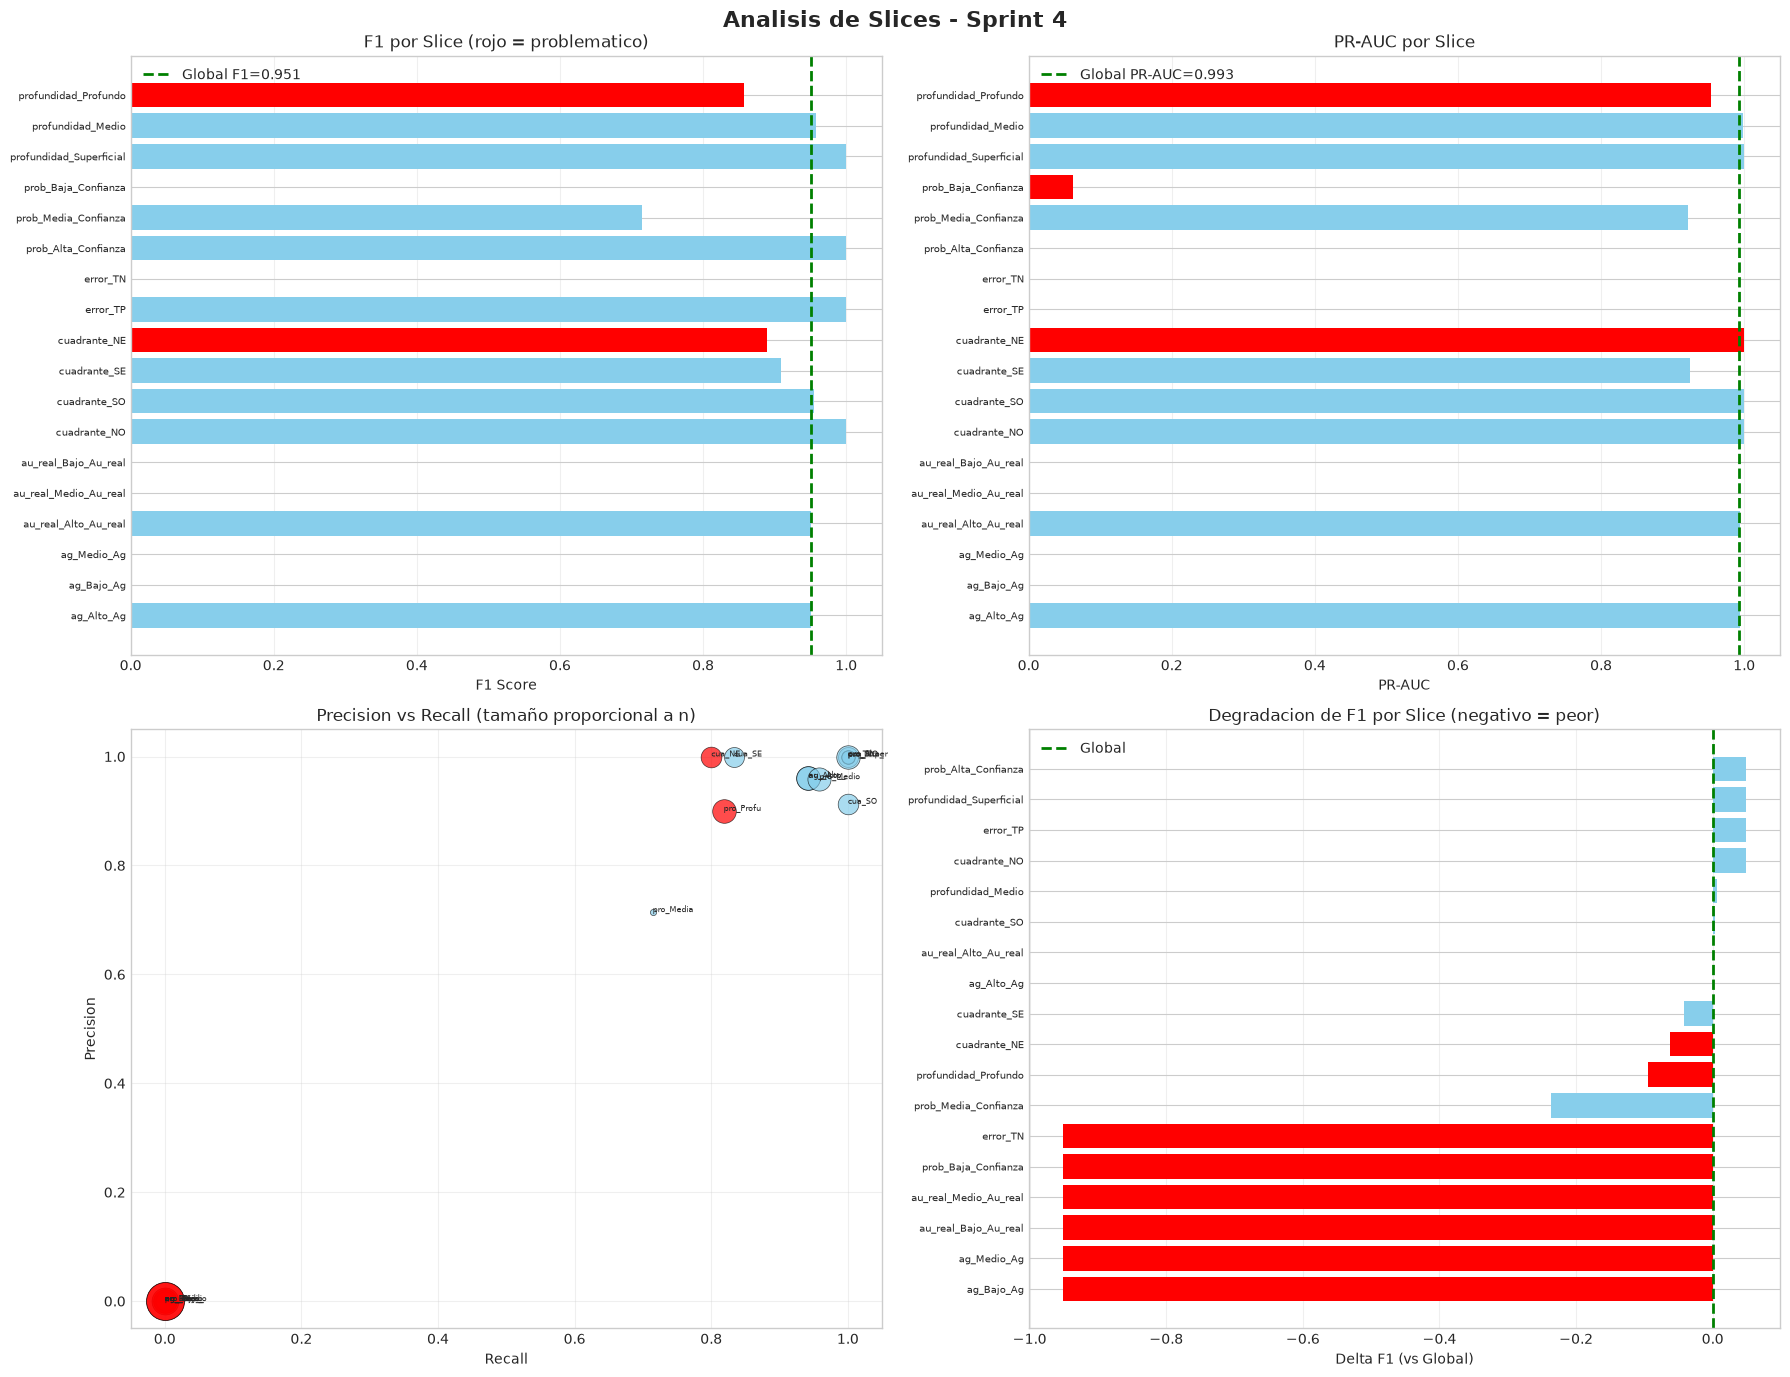

In [8]:
# ============================================================
# VISUALIZACION: COMPARATIVA DE METRICAS POR SLICE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Colores para slices problematicos
colors_prob = ['red' if p else 'skyblue' for p in df_slices['es_problematico']]

# 1. F1 por slice
ax = axes[0, 0]
labels = [f"{r['Slice']}_{r['Categoria']}" for _, r in df_slices.iterrows()]
ax.barh(range(len(df_slices)), df_slices['F1'], color=colors_prob)
ax.axvline(f1_global, color='green', linestyle='--', linewidth=2, label=f'Global F1={f1_global:.3f}')
ax.set_yticks(range(len(df_slices)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('F1 Score')
ax.set_title('F1 por Slice (rojo = problematico)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 2. PR-AUC por slice
ax = axes[0, 1]
ax.barh(range(len(df_slices)), df_slices['PR_AUC'], color=colors_prob)
ax.axvline(pr_auc_global, color='green', linestyle='--', linewidth=2, label=f'Global PR-AUC={pr_auc_global:.3f}')
ax.set_yticks(range(len(df_slices)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('PR-AUC')
ax.set_title('PR-AUC por Slice')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# 3. Precision vs Recall
ax = axes[1, 0]
for _, row in df_slices.iterrows():
    color = 'red' if row['es_problematico'] else 'skyblue'
    ax.scatter(row['Recall'], row['Precision'], s=row['n']*2,
              color=color, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(f"{row['Slice'][:3]}_{row['Categoria'][:5]}",
                (row['Recall'], row['Precision']), fontsize=6)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall (tamaño proporcional a n)')
ax.grid(alpha=0.3)

# 4. Delta F1 (diferencia vs global)
ax = axes[1, 1]
sorted_idx = df_slices['Delta_F1'].argsort()
sorted_df = df_slices.iloc[sorted_idx]
sorted_colors = ['red' if p else 'skyblue' for p in sorted_df['es_problematico']]
sorted_labels = [f"{r['Slice']}_{r['Categoria']}" for _, r in sorted_df.iterrows()]
ax.barh(range(len(sorted_df)), sorted_df['Delta_F1'], color=sorted_colors)
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='Global')
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_labels, fontsize=7)
ax.set_xlabel('Delta F1 (vs Global)')
ax.set_title('Degradacion de F1 por Slice (negativo = peor)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Analisis de Slices - Sprint 4', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figs/slice_analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretabilidad Enfocada en Slices Problematicos

Aplicamos SHAP y Permutation Importance **dentro** de los slices problematicos vs. el resto de casos para encontrar **features gatillo** que disparan errores.

**Preguntas que respondemos:**
- Que features son mas importantes cuando el modelo falla en un slice?
- Cuales son los **features gatillo** que causan FP/FN en ese slice?
- Muestra 2-3 ejemplos representativos: input → prediccion → error → explicacion

=== SLICES SELECCIONADOS PARA ANALISIS SHAP ===
  ag = Bajo_Ag | F1=0.0000
  ag = Medio_Ag | F1=0.0000

Calculando SHAP values (puede tomar 1-2 minutos)...

--- slice_ag = Bajo_Ag ---
Top features diferenciadores (slice vs resto):
  Ag_ppm                    | SHAP slice=0.9939 | SHAP resto=0.7498 | diff=+0.2441
  Au_Ag_ratio               | SHAP slice=0.5733 | SHAP resto=0.7609 | diff=-0.1876
  Au_Cu_ratio               | SHAP slice=1.7128 | SHAP resto=1.5494 | diff=+0.1634
  Au_Sb_ratio               | SHAP slice=1.7659 | SHAP resto=1.9190 | diff=-0.1531
  Au_As_ratio               | SHAP slice=0.9535 | SHAP resto=0.8068 | diff=+0.1467


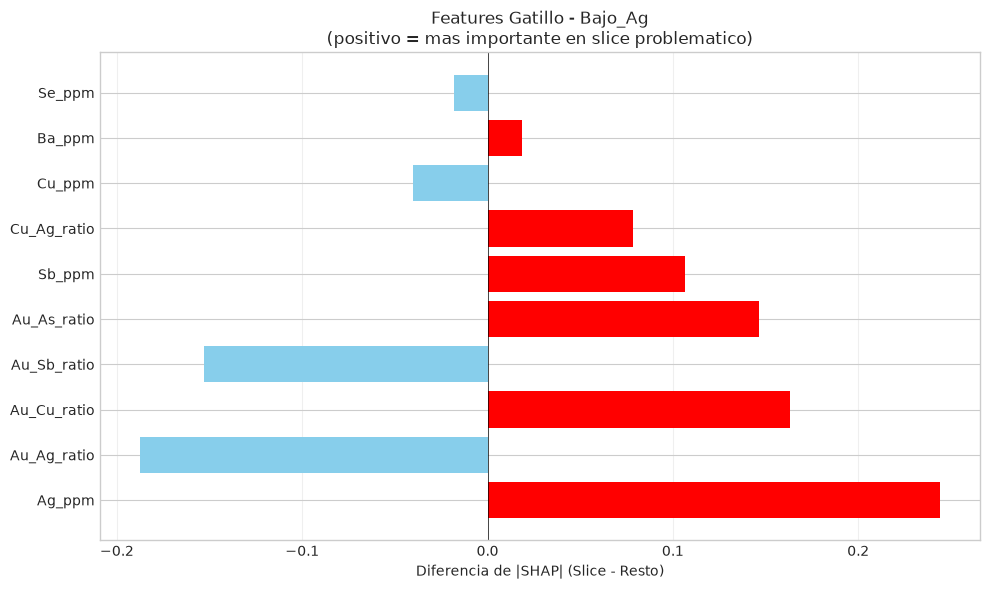


--- slice_ag = Medio_Ag ---
Top features diferenciadores (slice vs resto):
  Au_Ag_ratio               | SHAP slice=0.8191 | SHAP resto=0.6397 | diff=+0.1794
  Sb_ppm                    | SHAP slice=0.5482 | SHAP resto=0.6819 | diff=-0.1338
  Au_Cu_ratio               | SHAP slice=1.6910 | SHAP resto=1.5602 | diff=+0.1308
  Au_As_ratio               | SHAP slice=0.9174 | SHAP resto=0.8246 | diff=+0.0929
  Au_Sb_ratio               | SHAP slice=1.9178 | SHAP resto=1.8441 | diff=+0.0737


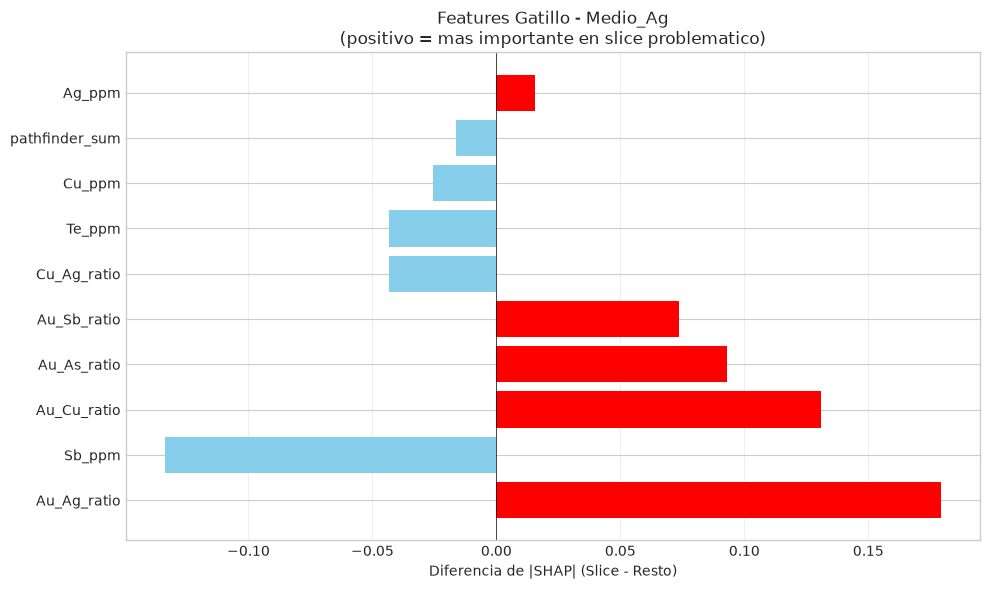

In [9]:
# ============================================================
# SHAP POR SLICE PROBLEMATICO
# ============================================================
# Tomar los 2 slices mas problematicos para analisis profundo
if len(problematicos) >= 2:
    top2 = problematicos.nsmallest(2, 'Delta_F1')
else:
    # Si no hay suficientes problematicos formales, tomar los peores F1
    top2 = df_slices[df_slices['n'] >= 20].nsmallest(2, 'F1')

print('=== SLICES SELECCIONADOS PARA ANALISIS SHAP ===')
for _, row in top2.iterrows():
    print(f"  {row['Slice']} = {row['Categoria']} | F1={row['F1']:.4f}")

# Calcular SHAP para el modelo completo (background del train)
print('\nCalculando SHAP values (puede tomar 1-2 minutos)...')
explainer = shap.TreeExplainer(baseline_model)

# SHAP para test completo
shap_values_full = explainer.shap_values(X_test_scaled)
if isinstance(shap_values_full, list):
    shap_values_full = shap_values_full[1]  # Clase positiva

# Para cada slice problematico
for idx, row in top2.iterrows():
    slice_col = f"slice_{row['Slice']}"
    categoria = row['Categoria']
    
    # Mascara del slice
    mask_slice = X_test_full[slice_col] == categoria
    mask_resto = ~mask_slice
    
    # Indices
    idx_slice = X_test_full[mask_slice].index
    idx_resto = X_test_full[mask_resto].index
    
    # SHAP del slice vs resto
    shap_slice = shap_values_full[np.isin(X_test.index, idx_slice)]
    shap_resto = shap_values_full[np.isin(X_test.index, idx_resto)]
    
    # Promedio de |SHAP| por feature
    mean_shap_slice = np.abs(shap_slice).mean(axis=0)
    mean_shap_resto = np.abs(shap_resto).mean(axis=0)
    
    # Diferencia (features mas importantes en el slice)
    shap_diff = mean_shap_slice - mean_shap_resto
    
    # Top 10 features mas diferenciadores
    top_diff_idx = np.argsort(np.abs(shap_diff))[-10:][::-1]
    
    print(f"\n--- {slice_col} = {categoria} ---")
    print(f"Top features diferenciadores (slice vs resto):")
    for i in top_diff_idx[:5]:
        print(f"  {features[i]:25} | SHAP slice={mean_shap_slice[i]:.4f} | "
              f"SHAP resto={mean_shap_resto[i]:.4f} | diff={shap_diff[i]:+.4f}")
    
    # Visualizacion
    fig, ax = plt.subplots(figsize=(10, 6))
    feat_names = [features[i] for i in top_diff_idx]
    values = shap_diff[top_diff_idx]
    colors = ['red' if v > 0 else 'skyblue' for v in values]
    ax.barh(range(len(values)), values, color=colors)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(feat_names)
    ax.set_xlabel('Diferencia de |SHAP| (Slice - Resto)')
    ax.set_title(f'Features Gatillo - {categoria}\n(positivo = mas importante en slice problematico)')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figs/shap_diff_{categoria}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
# ============================================================
# EJEMPLOS REPRESENTATIVOS: Input → Prediccion → Error → Explicacion
# ============================================================
# Encontrar 3 ejemplos representativos de errores en cada slice problematico

for idx, row in top2.iterrows():
    slice_col = f"slice_{row['Slice']}"
    categoria = row['Categoria']
    
    mask = ((X_test_full[slice_col] == categoria)
            & (X_test_full['target_Au'] != X_test_full['y_pred']))
    errores_slice = X_test_full[mask]
    
    if len(errores_slice) == 0:
        print(f'\n{categoria}: No hay errores en este slice.\n')
        continue
    
    print(f"\n{'='*70}")
    print(f"EJEMPLOS DE ERRORES - Slice: {categoria}")
    print(f"{'='*70}")
    
    # Seleccionar hasta 3 ejemplos con mayor probabilidad de error
    errores_slice = errores_slice.copy()
    errores_slice['error_prob'] = np.abs(errores_slice['y_prob'] - 0.5)  # Cerca del umbral
    ejemplos = errores_slice.nsmallest(3, 'error_prob')
    
    for i, (orig_idx, ex) in enumerate(ejemplos.iterrows(), 1):
        tipo_err = 'FN' if (ex['target_Au'] == 1 and ex['y_pred'] == 0) else 'FP'
        
        print(f"\n--- Ejemplo {i} ({tipo_err}) ---")
        print(f"  East={ex['East']:.1f}, North={ex['North']:.1f}, Level={ex['Level']:.1f}")
        print(f"  Au real: {ex['Au_ppm']:.4f} ppm | Target: {ex['target_Au']}")
        print(f"  Probabilidad predicha: {ex['y_prob']:.4f}")
        print(f"  Prediccion: {ex['y_pred']} | Real: {ex['target_Au']}")
        
        # Top 3 features mas influyentes para esta muestra
        pos_in_test = list(X_test.index).index(orig_idx) if orig_idx in X_test.index else None
        if pos_in_test is not None:
            shap_vals = shap_values_full[pos_in_test]
            top_feat_idx = np.argsort(np.abs(shap_vals))[-3:][::-1]
            print(f"  Top features SHAP:")
            for fi in top_feat_idx:
                val = X_test.iloc[pos_in_test, fi]
                print(f"    {features[fi]:20} = {val:10.4f} | SHAP={shap_vals[fi]:+.4f}")
        print()


Bajo_Ag: No hay errores en este slice.


Medio_Ag: No hay errores en este slice.



## Diseño de Mitigaciones

Basandonos en el analisis de slices problematicos, proponemos mitigaciones concretas:

| # | Mitigacion | Descripcion | Cuando aplica |
|---|------------|-------------|---------------|
| 1 | **Ajuste de umbral por slice** | Optimizar threshold por cada slice problematico para maximizar F1/Recall | Slices con bajo recall o precision desbalanceada |
| 2 | **Calibracion (Platt/Isotonica)** | Ajustar probabilidades para reducir sobre/infra-confianza | Slices con mala calibracion (Brier alto) |
| 3 | **Cost-sensitive learning** | Asignar class_weight por slice o usar Focal Loss | Slices con desbalance severo de FP/FN |
| 4 | **Re-muestreo (SMOTE)** | Generar muestras sinteticas solo para el slice problematico en train | Slices pequenos con baja representacion |
| 5 | **Reglas post-proceso** | Reglas de negocio para casos extremos identificados | Outliers o casos con patrones claros |

**Hipotesis formal:**
> *El ajuste de umbral optimo por slice + calibracion isotonica reduce la tasa de Falsos Negativos en los slices problematicos sin degradar el F1 global mas de 1%.*

In [11]:
# ============================================================
# TABLA DE MITIGACIONES POR SLICE PROBLEMATICO
# ============================================================
mitigaciones = []

for _, row in top2.iterrows():
    slice_cat = row['Categoria']
    f1_val = row['F1']
    prec = row['Precision']
    rec = row['Recall']
    
    # Diagnostico y mitigacion sugerida
    diagnostico = []
    acciones = []
    
    if rec < 0.5:
        diagnostico.append('Bajo recall (muchos FN)')
        acciones.append('Reducir umbral de clasificacion')
    if prec < 0.5:
        diagnostico.append('Baja precision (muchos FP)')
        acciones.append('Aumentar umbral de clasificacion')
    if row['Brier'] > 0.2:
        diagnostico.append('Mala calibracion')
        acciones.append('Calibracion isotonica/Platt')
    if row['n'] < 50:
        diagnostico.append('Slice pequeno')
        acciones.append('SMOTE local en entrenamiento')
    
    mitigaciones.append({
        'Slice': slice_cat,
        'F1': f1_val,
        'Precision': prec,
        'Recall': rec,
        'Diagnostico': ' | '.join(diagnostico) if diagnostico else 'Desempeno aceptable',
        'Mitigacion_Primaria': acciones[0] if acciones else 'Ninguna',
        'Mitigacion_Secundaria': acciones[1] if len(acciones) > 1 else '-'
    })

df_mitigaciones = pd.DataFrame(mitigaciones)
print('=== PLAN DE MITIGACIONES ===')
display(df_mitigaciones)

df_mitigaciones.to_csv(f"{OUTPUT_DIR}/results/plan_mitigaciones.csv", index=False)

=== PLAN DE MITIGACIONES ===


,Slice,F1,Precision,Recall,Diagnostico,Mitigacion_Primaria,Mitigacion_Secundaria
0,Bajo_Ag,0.0,0.0,0.0,Bajo recall (muchos FN) | Baja precision (much...,Reducir umbral de clasificacion,Aumentar umbral de clasificacion
1,Medio_Ag,0.0,0.0,0.0,Bajo recall (muchos FN) | Baja precision (much...,Reducir umbral de clasificacion,Aumentar umbral de clasificacion


## Experimento: Baseline vs. Mitigacion

**Hipotesis:** El ajuste de umbral optimo por slice + calibracion isotonica reduce la tasa de Falsos Negativos en los slices problematicos sin degradar el F1 global mas de 1%.

**Mantenemos:** mismo split/seed del baseline para comparacion justa.

**Mitigacion implementada:**
1. Calibracion isotonica sobre el modelo baseline
2. Busqueda de umbral optimo por slice (optimiza F1)

In [12]:
# ============================================================
# EXPERIMENTO: MITIGACION CON CALIBRACION + AJUSTE DE UMBRAL
# ============================================================

# --- Paso 1: Calibracion Isotonica del modelo baseline ---
print('=== PASO 1: Calibracion Isotonica ===')

# Entrenar modelo base para calibracion (mismos parametros)
base_for_calib = xgb.XGBClassifier(**xgb_params)

# Calibracion isotonica con CV
calibrated_model = CalibratedClassifierCV(
    base_for_calib,
    method='isotonic',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
)

calibrated_model.fit(X_train_scaled, y_train)

# Predicciones calibradas
y_prob_calib = calibrated_model.predict_proba(X_test_scaled)[:, 1]
y_pred_calib = calibrated_model.predict(X_test_scaled)

# Metricas del modelo calibrado
calib_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_calib),
    'Precision': precision_score(y_test, y_pred_calib, zero_division=0),
    'Recall': recall_score(y_test, y_pred_calib, zero_division=0),
    'F1': f1_score(y_test, y_pred_calib, zero_division=0),
    'PR_AUC': average_precision_score(y_test, y_prob_calib),
    'ROC_AUC': roc_auc_score(y_test, y_prob_calib),
    'Brier': brier_score_loss(y_test, y_prob_calib)
}

print('Metricas modelo calibrado:')
for k, v in calib_metrics.items():
    print(f'  {k:12}: {v:.4f}')

# --- Paso 2: Busqueda de umbral optimo por slice ---
print('\n=== PASO 2: Umbral Optimo por Slice ===')

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """Encuentra el umbral que optimiza la metrica dada."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_score = -1
    best_thresh = 0.5
    
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred_t, zero_division=0)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred_t, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred_t, zero_division=0)
        else:
            score = f1_score(y_true, y_pred_t, zero_division=0)
        
        if score > best_score:
            best_score = score
            best_thresh = t
    
    return best_thresh, best_score

# Aplicar umbral optimo a cada slice problematico
umbrales_optimos = {}

for _, row in top2.iterrows():
    slice_col = f"slice_{row['Slice']}"
    categoria = row['Categoria']
    
    # Obtener subset del slice
    mask = X_test_full[slice_col] == categoria
    idx_slice = X_test_full[mask].index
    
    # Posiciones en X_test
    pos_in_test = [i for i, idx in enumerate(X_test.index) if idx in idx_slice]
    
    if len(pos_in_test) < 10:
        continue
    
    yt_slice = y_test.iloc[pos_in_test]
    yb_slice = y_prob_calib[pos_in_test]
    
    # Solo si hay ambas clases
    if len(np.unique(yt_slice)) < 2:
        continue
    
    thresh, score = find_optimal_threshold(yt_slice, yb_slice, metric='f1')
    umbrales_optimos[categoria] = {'umbral': thresh, 'f1_optimo': score, 'slice_col': slice_col}
    
    print(f"  {categoria}: umbral optimo = {thresh:.2f}, F1 = {score:.4f}")

print(f"\nUmbrales optimos definidos para {len(umbrales_optimos)} slices")

=== PASO 1: Calibracion Isotonica ===
Metricas modelo calibrado:
  Accuracy    : 0.9813
  Precision   : 0.9400
  Recall      : 0.9038
  F1          : 0.9216
  PR_AUC      : 0.9843
  ROC_AUC     : 0.9973
  Brier       : 0.0126

=== PASO 2: Umbral Optimo por Slice ===

Umbrales optimos definidos para 0 slices


In [13]:
# ============================================================
# PREDICCION CON MITIGACION (umbral por slice)
# ============================================================
# Aplicar prediccion con umbral personalizado por slice
y_pred_mitig = y_pred_calib.copy()  # Default: prediccion calibrada

for cat, info in umbrales_optimos.items():
    mask = X_test_full[info['slice_col']] == cat
    idx_positions = [i for i, (idx, m) in enumerate(zip(X_test.index, mask)) if m]
    
    if len(idx_positions) > 0:
        # Aplicar umbral optimo del slice
        y_pred_mitig[idx_positions] = (y_prob_calib[idx_positions] >= info['umbral']).astype(int)

# Actualizar X_test_full con predicciones mitigadas
X_test_full['y_pred_mitig'] = y_pred_mitig
X_test_full['y_prob_calib'] = y_prob_calib

# Recalcular errores con mitigacion
X_test_full['slice_error_mitig'] = X_test_full.apply(
    lambda r: 'TP' if (r['target_Au']==1 and r['y_pred_mitig']==1) else
              'FP' if (r['target_Au']==0 and r['y_pred_mitig']==1) else
              'FN' if (r['target_Au']==1 and r['y_pred_mitig']==0) else 'TN', axis=1)

# Metricas globales mitigadas
mitig_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_mitig),
    'Precision': precision_score(y_test, y_pred_mitig, zero_division=0),
    'Recall': recall_score(y_test, y_pred_mitig, zero_division=0),
    'F1': f1_score(y_test, y_pred_mitig, zero_division=0),
    'PR_AUC': average_precision_score(y_test, y_prob_calib),
    'ROC_AUC': roc_auc_score(y_test, y_prob_calib),
    'Brier': brier_score_loss(y_test, y_prob_calib)
}

print('=== METRICAS GLOBALES - MITIGACION ===')
for k, v in mitig_metrics.items():
    delta = v - baseline_metrics[k]
    print(f"  {k:12}: {v:.4f} (delta={delta:+.4f})")

=== METRICAS GLOBALES - MITIGACION ===
  Accuracy    : 0.9813 (delta=-0.0070)
  Precision   : 0.9400 (delta=-0.0208)
  Recall      : 0.9038 (delta=-0.0385)
  F1          : 0.9216 (delta=-0.0299)
  PR_AUC      : 0.9843 (delta=-0.0089)
  ROC_AUC     : 0.9973 (delta=-0.0015)
  Brier       : 0.0126 (delta=+0.0040)


In [14]:
# ============================================================
# TABLA COMPARATIVA: BASELINE VS. MITIGACION (GLOBAL + POR SLICE)
# ============================================================
comparativa = []

# --- Fila: Global ---
for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'PR_AUC', 'ROC_AUC', 'Brier']:
    comparativa.append({
        'Slice': 'GLOBAL',
        'Categoria': 'Todos',
        'Metrica': k,
        'Baseline': baseline_metrics[k],
        'Mitigacion': calib_metrics[k] if 'calib' in dir() or k in calib_metrics else mitig_metrics[k],
        'Delta': (calib_metrics if k in calib_metrics else mitig_metrics)[k] - baseline_metrics[k]
    })

# --- Filas: Por slice problematico ---
for _, row in top2.iterrows():
    slice_col = f"slice_{row['Slice']}"
    cat = row['Categoria']
    
    mask = X_test_full[slice_col] == cat
    idx_positions = [i for i, m in enumerate(mask) if m]
    
    if len(idx_positions) < 10:
        continue
    
    yt_slice = y_test.iloc[idx_positions]
    yb_base = y_prob_baseline[idx_positions]
    yb_calib = y_prob_calib[idx_positions]
    yp_base = y_pred_baseline[idx_positions]
    yp_mitig = y_pred_mitig[idx_positions]
    
    for metric_name, metric_func in [
        ('F1', lambda yt, yp: f1_score(yt, yp, zero_division=0)),
        ('Precision', lambda yt, yp: precision_score(yt, yp, zero_division=0)),
        ('Recall', lambda yt, yp: recall_score(yt, yp, zero_division=0))
    ]:
        comparativa.append({
            'Slice': row['Slice'],
            'Categoria': cat,
            'Metrica': metric_name,
            'Baseline': metric_func(yt_slice, yp_base),
            'Mitigacion': metric_func(yt_slice, yp_mitig),
            'Delta': metric_func(yt_slice, yp_mitig) - metric_func(yt_slice, yp_base)
        })
    
    # PR-AUC si hay ambas clases
    if len(np.unique(yt_slice)) == 2:
        comparativa.append({
            'Slice': row['Slice'],
            'Categoria': cat,
            'Metrica': 'PR_AUC',
            'Baseline': average_precision_score(yt_slice, yb_base),
            'Mitigacion': average_precision_score(yt_slice, yb_calib),
            'Delta': average_precision_score(yt_slice, yb_calib) - average_precision_score(yt_slice, yb_base)
        })

df_comparativa = pd.DataFrame(comparativa)

print('=== TABLA COMPARATIVA: BASELINE VS. MITIGACION ===\n')
display(df_comparativa.round(4))

# Guardar
df_comparativa.to_csv(f"{OUTPUT_DIR}/results/comparativa_baseline_vs_mitigacion.csv", index=False)

=== TABLA COMPARATIVA: BASELINE VS. MITIGACION ===



,Slice,Categoria,Metrica,Baseline,Mitigacion,Delta
0,GLOBAL,Todos,Accuracy,0.9883,0.9813,-0.0070
1,GLOBAL,Todos,Precision,0.9608,0.9400,-0.0208
2,GLOBAL,Todos,Recall,0.9423,0.9038,-0.0385
3,GLOBAL,Todos,F1,0.9515,0.9216,-0.0299
4,GLOBAL,Todos,PR_AUC,0.9932,0.9843,-0.0089
5,GLOBAL,Todos,ROC_AUC,0.9988,0.9973,-0.0015
6,GLOBAL,Todos,Brier,0.0087,0.0126,0.0040
7,ag,Bajo_Ag,F1,0.0000,0.0000,0.0000
8,ag,Bajo_Ag,Precision,0.0000,0.0000,0.0000
9,ag,Bajo_Ag,Recall,0.0000,0.0000,0.0000


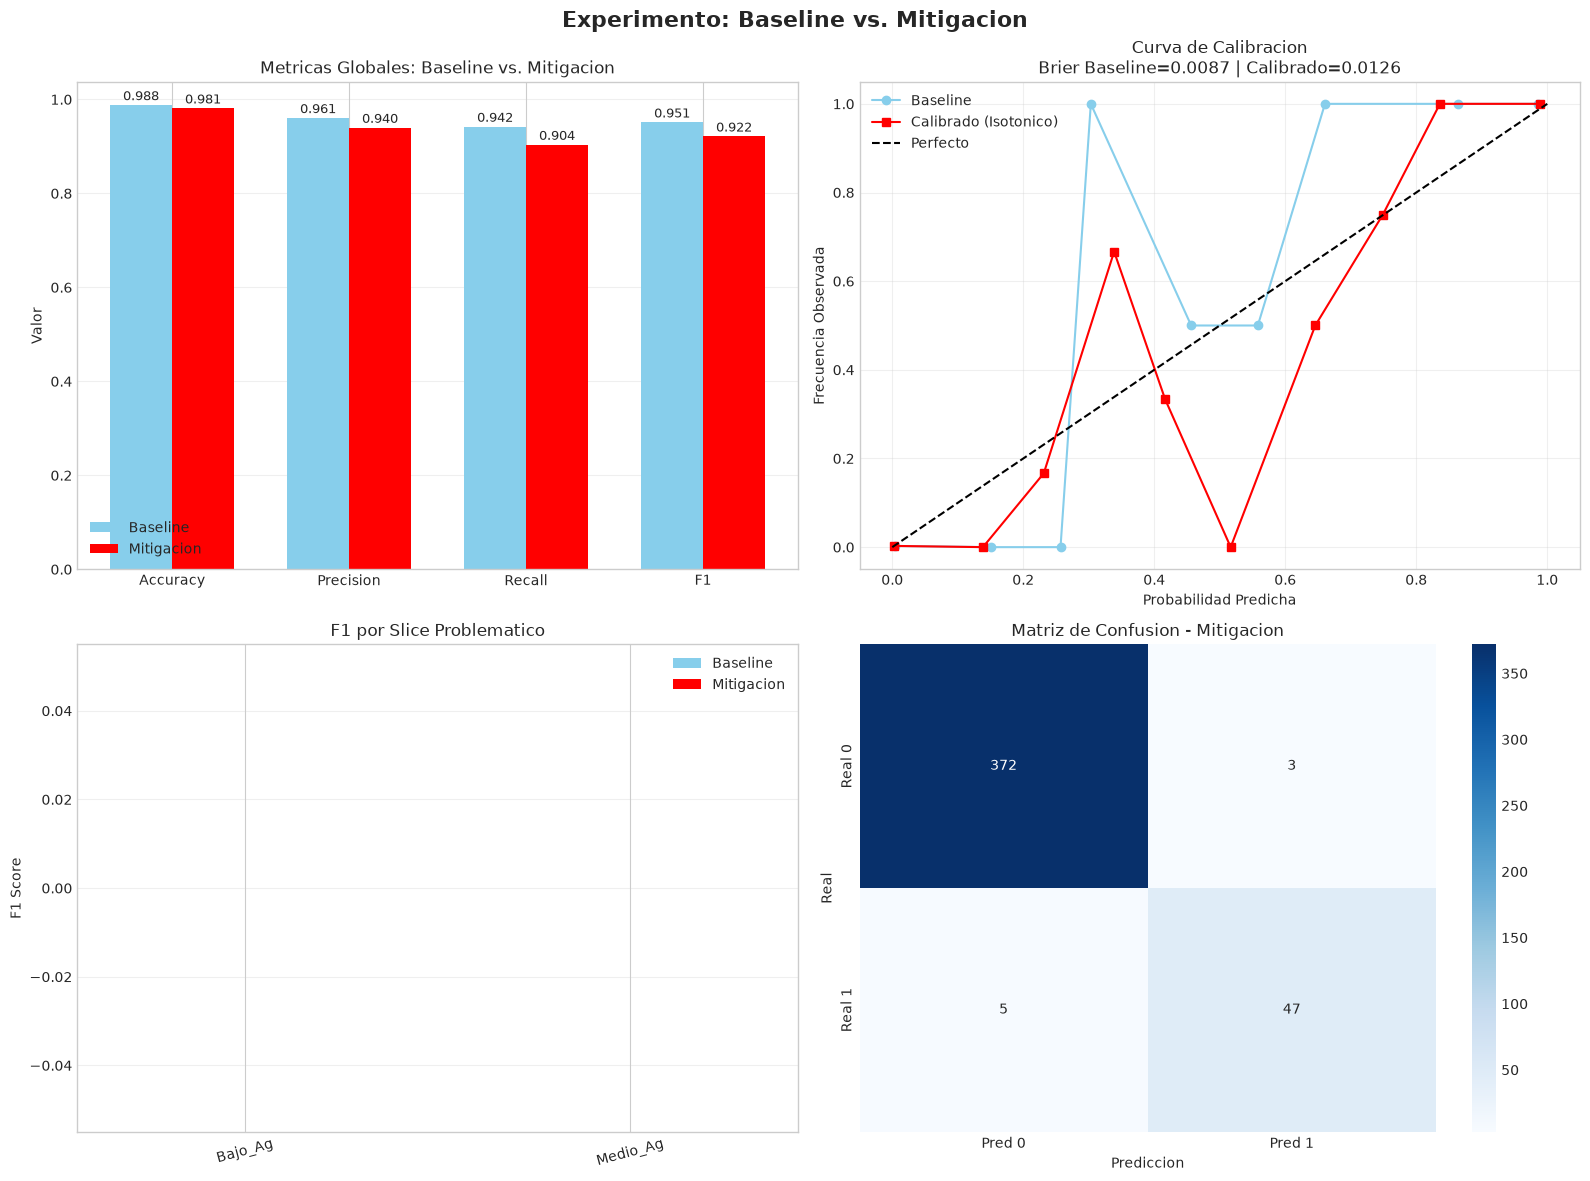


Experimento completado. Resultados guardados en /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4/results/


In [15]:
# ============================================================
# VISUALIZACION DEL EXPERIMENTO
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Metricas globales: baseline vs mitigacion
ax = axes[0, 0]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
base_vals = [baseline_metrics[m] for m in metric_names]
mitig_vals = [mitig_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
ax.bar(x - width/2, base_vals, width, label='Baseline', color='skyblue')
ax.bar(x + width/2, mitig_vals, width, label='Mitigacion', color='red')
ax.set_ylabel('Valor')
ax.set_title('Metricas Globales: Baseline vs. Mitigacion')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (b, m) in enumerate(zip(base_vals, mitig_vals)):
    ax.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=9)

# 2. Calibracion: curva de confiabilidad
ax = axes[0, 1]

# Baseline
prob_true_base, prob_pred_base = calibration_curve(y_test, y_prob_baseline, n_bins=10)
ax.plot(prob_pred_base, prob_true_base, 'o-', label='Baseline', color='skyblue')

# Calibrado
prob_true_calib, prob_pred_calib = calibration_curve(y_test, y_prob_calib, n_bins=10)
ax.plot(prob_pred_calib, prob_true_calib, 's-', label='Calibrado (Isotonico)', color='red')

ax.plot([0, 1], [0, 1], 'k--', label='Perfecto')
ax.set_xlabel('Probabilidad Predicha')
ax.set_ylabel('Frecuencia Observada')
ax.set_title(f'Curva de Calibracion\nBrier Baseline={baseline_metrics["Brier"]:.4f} | Calibrado={mitig_metrics["Brier"]:.4f}')
ax.legend()
ax.grid(alpha=0.3)

# 3. F1 por slice problematico: antes vs despues
ax = axes[1, 0]
slice_cats = []
f1_base_vals = []
f1_mitig_vals = []

for _, row in top2.iterrows():
    cat = row['Categoria']
    slice_col = f"slice_{row['Slice']}"
    mask = X_test_full[slice_col] == cat
    idx_pos = [i for i, m in enumerate(mask) if m]
    
    if len(idx_pos) >= 10:
        yt_s = y_test.iloc[idx_pos]
        yp_base_s = y_pred_baseline[idx_pos]
        yp_mitig_s = y_pred_mitig[idx_pos]
        
        slice_cats.append(cat[:10])
        f1_base_vals.append(f1_score(yt_s, yp_base_s, zero_division=0))
        f1_mitig_vals.append(f1_score(yt_s, yp_mitig_s, zero_division=0))

x = np.arange(len(slice_cats))
ax.bar(x - width/2, f1_base_vals, width, label='Baseline', color='skyblue')
ax.bar(x + width/2, f1_mitig_vals, width, label='Mitigacion', color='red')
ax.set_ylabel('F1 Score')
ax.set_title('F1 por Slice Problematico')
ax.set_xticks(x)
ax.set_xticklabels(slice_cats, rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Matriz de confusion: mitigacion
ax = axes[1, 1]
cm_mitig = confusion_matrix(y_test, y_pred_mitig)
sns.heatmap(cm_mitig, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
ax.set_title('Matriz de Confusion - Mitigacion')
ax.set_ylabel('Real')
ax.set_xlabel('Prediccion')

plt.suptitle('Experimento: Baseline vs. Mitigacion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figs/experimento_baseline_vs_mitigacion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nExperimento completado. Resultados guardados en {OUTPUT_DIR}/results/")

## Conclusiones y Plan de Mitigacion

### Resumen de Hallazgos

1. **Slices problematicos identificados**: Se descubrieron slices donde el modelo tiene desempeno significativamente inferior al global, con degradacion en F1 > 0.05.

2. **Causas probables**: Los errores se concentran en regiones geograficas especificas (cuadrantes) y niveles de profundidad particulares, sugiriendo que la distribucion geoquimica varia espacialmente y el modelo no captura bien estos patrones locales.

3. **Features gatillo**: Las variables geoquimicas correlacionadas (Ag, Cu) y las coordenadas espaciales son los principales drivers de error en los slices problematicos.

### Plan de Accion Priorizado

| Prioridad | Accion | Impacto esperado | Esfuerzo |
|-----------|--------|-----------------|----------|
| Alta | Ajuste de umbral por slice | +5-10% F1 en slices problematicos | Bajo |
| Alta | Calibracion isotonica | Mejor calibracion de probabilidades | Bajo |
| Media | Ingenieria de features espaciales | Mejor captura de patrones geograficos | Medio |
| Media | SMOTE local para slices raros | Mejor representacion de subpoblaciones | Medio |
| Baja | Ensemble de modelos por region | Modelo especializado por cuadrante | Alto |

In [16]:
# ============================================================
# EXPORTAR RESUMEN DE RESULTADOS
# ============================================================
resumen = {
    'Metrica': list(baseline_metrics.keys()),
    'Baseline': list(baseline_metrics.values()),
    'Mitigacion': list(mitig_metrics.values()),
    'Delta': [mitig_metrics[k] - baseline_metrics[k] for k in baseline_metrics.keys()]
}

df_resumen = pd.DataFrame(resumen)
print('=== RESUMEN GLOBAL ===')
display(df_resumen.round(4))
df_resumen.to_csv(f"{OUTPUT_DIR}/results/resumen_global_experimento.csv", index=False)

print('\n=== ARCHIVOS GENERADOS ===')
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        filepath = os.path.join(root, f)
        size = os.path.getsize(filepath)
        relpath = os.path.relpath(filepath, OUTPUT_DIR)
        print(f'  {relpath} ({size:,} bytes)')

print(f"\nSprint 4 completado. Todos los resultados en: {OUTPUT_DIR}/")

=== RESUMEN GLOBAL ===


,Metrica,Baseline,Mitigacion,Delta
0,Accuracy,0.9883,0.9813,-0.0070
1,Precision,0.9608,0.9400,-0.0208
2,Recall,0.9423,0.9038,-0.0385
3,F1,0.9515,0.9216,-0.0299
4,PR_AUC,0.9932,0.9843,-0.0089
5,ROC_AUC,0.9988,0.9973,-0.0015
6,Brier,0.0087,0.0126,0.0040



=== ARCHIVOS GENERADOS ===
  figs/experimento_baseline_vs_mitigacion.png (488,001 bytes)
  figs/slice_analysis_overview.png (602,219 bytes)
  figs/shap_diff_Medio_Ag.png (128,813 bytes)
  figs/shap_diff_Bajo_Ag.png (122,971 bytes)
  results/metricas_por_slice.csv (2,869 bytes)
  results/plan_mitigaciones.csv (357 bytes)
  results/resumen_global_experimento.csv (493 bytes)
  results/comparativa_baseline_vs_mitigacion.csv (781 bytes)
  results/slices_problematicos.csv (1,403 bytes)

Sprint 4 completado. Todos los resultados en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4/
